# RDKit 

## What is RDKit ? 

RDKit is an open-source python toolkit for cheminformatics, widely used in academia and industry for representing, transforming, analysing, adn learning from molecular structures. 

At it's core, RDKit treat molecules as graphs:

* atoms -> nodes
* bonds -> edges

## Why RDKit matters ?

What can you do in it ?

RDKit sits at the boundary between: 

* Chemistry (structure, reactivity, functional groups)
* Mathematics (graphs, descriptors, similarity metrics)
* Machine learning (features, fingerprints, embeddings)

Because of this, it is often the *first* tool used before:

* Quantum chemistry (Psi4/PySCF)
* Molecular dynamics (OpenMM)
* ML pipelines (scikit-learn, PyTorch)

## Goals of this notebook

This notebook focuses on **fundamentals**, not application:

* Creating molecules from SMILES
* Inspecting atoms and bonds
* Understanding molecular properties and descriptors 
* Building intuition for how chemistry becomes data

code original documentation: https://www.rdkit.org/docs/api-docs.html

=======================================================================================================================================
Author's note:

* This notebook is not meant for pure rdkit reference or learning notes.
* It is used for containing my messy analogies, explanations and basically my attempts at taming this wonderfull tool
* Mentions or relations of AI/ML, or any other things that may look irrelevant may appear
* This is because i'm a polymath that studies a variety of things such as:
1) Computational science (with a focus on computational chemistry) (as you might know)
2) Bioinformatics
3) Artificial Intelligence and Machine Learning (AI/ML)
4) Quantitative Finance
5) Mathematics 
6) Chemistry (with a focus on physical chemistry and modelling)
7) OMICS 
8) Quantum mechanics
9) and a few othe things that I don't really wanna mention cause it'll be toooo looooong

* Anyhow, sorry to the one reading this notebook, if you find this notebook messy
* Because it is also a node of the amalgamation of my skills (in simple words, I use analogies from other fields to explain things hehe)
* Kind, regards, Animosius (as stated in this repo (though if you want my real name, hit me up with a job offer hehe)
* I wish you luck in your endeavours, take care !

ps:

Some of the notebook segment might become it's own notebook if it became too long lol

# What people use RDKKit for 

1. Molecular representation 

* SMILES <-> moleccule objects
* Canonicalization
* Sanitation & valence checking

2. Descriptors and fingerprints
Used for QSAR, ML, clustering, screening

* Morgan fingerprints (ECFP)
* MACCS keys
* Physicochemical descriptors (MW, logP, TPSA)

(This is where RDKit feeds scikit-learn/Pytorch)

3. Similarity and screening

* Tanimoto similarity 
* Substructure matching
* Virtual screening of compound libraries 

(Pharma lives here) 

4. Structure manipulation

* Fragmentation 
* Functional group detection
* Reaction SMARTS (basic reaction modeling)

(not quantum chemistry, but very powerful chemically)

5. Pre- and post-processing for comp-chem

* Before QM (Generate conformers, clean structures)
* After QM (analyse, cluster, label results)

# 1.1. Molecules as Data Structures
Purpose: Understand what a molecule is in RDKit.

Concepts:
* Molecules =! picture
* Atoms, bonds, indices
* RDKit molecules are graphs

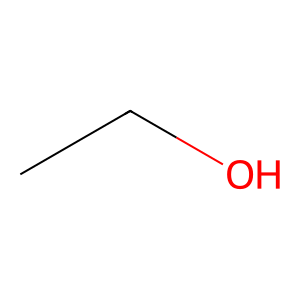

In [4]:
# Setup
from rdkit import Chem
from rdkit.Chem import Draw

mol = Chem.MolFromSmiles("CCO") # Ethanol
Draw.MolToImage(mol)

# 1.2 SMILES, Canonicalization, and Validity 
purpose: learn how chemistry becomes text and back

Concepts: 
* SMILES is not unique
* Canonical SMILES
* Sanitization & failure cases


# 1.3. Molecular Properties (Descriptors 101)
purpose: Turn chemistry into numbers

Concepts:
* Scalar descriptors vs fingerprints
* What descriptors mean chemically



# 1.4. Fingerprints & Similarity (CORE PRACTICES)

Purpose: This is where industry lives

Concepts 
* Fingerprints =! descriptors 
* Morgan /ECFP
* Tanimoto similarity 

# 1.5 Substructure & SMARTS (chemical intuition)

Purpose: Teach the computer chemistry concepts

* SMARTS =! SMILES
* Functional group detection

# 1.6. Conformers & 3D  (BRIDGE TO QM/MD)

Purpose: Prepare molecules for physics

Concepts:
* 2D vs 3D 
* Conformer ensembles
* Why this matter for QM & MD

# 1.7. RDKit + MAchine Learning (Fluency)

Purpose: Use RDKits as a feature engine 

Concepts
* Feature matrices 
* Labels vs structures
* Wy RDKit + sklearn is everywhere

# 1.8. Final Reflection Cell

* What RDKit is good at 
* What it should never be used for 
* How it connects to:
1) Docking 
2) MD
3) QM descriptors 
4) ML models

## The text above is the...ideal way to make organize things
## Now since learning is not "ideal" in organization.
## Let's start

# 2. The real fun

## 2.1 Introductory 
This is where we import stuff and etc

notes:
1. `rdkit.Chem (The Core)`
This is the heart of the library. If you don't import this, you don't have a molecule.

Purpose: Loading and saving molecules (MolFromSmiles, MolToPDBBlock).

Key Skill: Sanitization. This is the process where RDKit checks if your molecule's valence is correct. If sanitization fails, PySCF will 
likely crash because the electron count won't make sense.

`2. rdkit.Chem.AllChem (The Swiss Army Knife)`

While Chem handles the "What," AllChem handles the "How."

Purpose: 3D Conformer generation and Force Field optimization.

Why you'll use it: Before you run a PySCF calculation, you need a starting 3D geometry. 
You use AllChem.EmbedMolecule() to create that initial $x, y, z$ coordinate set.

`3. rdkit.Chem.Descriptors (The Numbers)`

Purpose: Calculating physical properties ($logP$, Molecular Weight, TPSA).

Why you'll use it: To filter your datasets. If you are preparing a MD simulation for a protein-ligand system in OpenMM, you might use this module to ensure your ligand isn't too large or too insoluble for the water box you've built.

`4. rdkit.Chem.rdMolDescriptors (The Advanced Stats)`

Purpose: More complex features like Gasteiger Charges.

Why you'll use it: Crucial for OpenMM. Standard SMILES don't have partial charges. To run Dynamics, you need to know how the electrons are distributed. This module allows you to calculate those charges programmatically.

`5. rdkit.Chem.Draw (The Eyes)`

Purpose: Visualizing your results in Jupyter Notebooks.

Why you'll use it: Sanity checks. If you "mutate" a molecule programmatically, you need to see if you accidentally turned a Benzene ring into a 5-legged monster before you waste 10 hours of GPU time on it.

Now, the notes above are mostly AI made (shoutout to gemini). so if you really wanna see what happens, see the code, hehe

In [4]:
# Setup 
from rdkit import Chem
from rdkit.Chem import Draw 
from rdkit.Chem import AllChem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors

# Weapon unlocked 

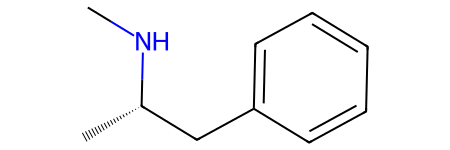

In [5]:
methamphetamine = Chem.MolFromSmiles("C[C@@H](CC1=CC=CC=C1)NC")

methamphetamine

# cool we just put methamphetamine in the memmory !

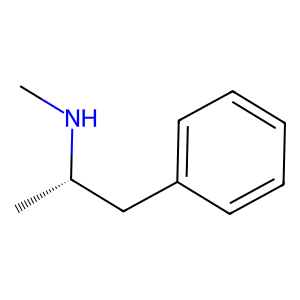

In [6]:
# Now let's see 
Draw.MolToImage(methamphetamine)

In [7]:
# A better/ summarized pipeline

methamphetamine = Chem.MolFromSmiles("C[C@@H](CC1=CC=CC=C1)NC")

# Check if molecule was made successfully
if methamphetamine != None:
    img=Draw.MolToImage(methamphetamine) # Draw creates an image object, then  it is saved to img variable for further commands
    img.show()
    print(f"Molecule: {methamphetamine} succesfully made !")
    print(f"Number of bonds: {methamphetamine.GetNumAtoms()}")
    print(f"Number of bonds: {methamphetamine.GetNumBonds()}")
else:
    print("Molecule wasn't created successfully !")

Molecule: <rdkit.Chem.rdchem.Mol object at 0x71e21b51f760> succesfully made !
Number of bonds: 11
Number of bonds: 11


# 2.2 Foundations

In [8]:
from rdkit import Chem # Molecule objects
from rdkit.Chem import Draw # Visualisaton

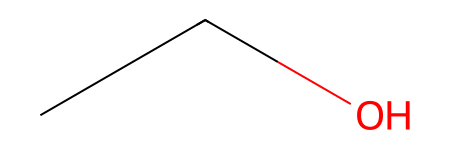

In [9]:
mol = Chem.MolFromSmiles("CCO")
mol
# Tip: RDKit usually builds molecules with smiles

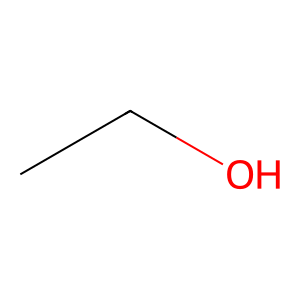

In [10]:
# Visualise molecules
Draw.MolToImage(mol)

In [11]:
# inspect atoms
for atoms in mol.GetAtoms():
    print(atoms.GetSymbol(), atoms.GetIdx())

# Remember: RDKit represents molecules in Graphs

C 0
C 1
O 2


In [12]:
# Count atoms
mol.GetNumAtoms() # There are three atoms in an ethanol molecule aside from hydrogens

3

In [13]:
# Count bonds
mol.GetNumAtoms() # There are three bonds (not including C-H) in an ethanol atom


3

* `mol.GetNumAtoms()` 
* `mol.GetNumBonds()`

Are commonly used for :
* datasets
* descriptors
* ML Pipelines

In [14]:
# Get molecular formulas

from rdkit.Chem import rdMolDescriptors

rdMolDescriptors.CalcMolFormula(mol)


'C2H6O'

In [15]:
# Calculating molecular weight 

from rdkit.Chem.Descriptors import MolWt

MolWt(mol)

46.069

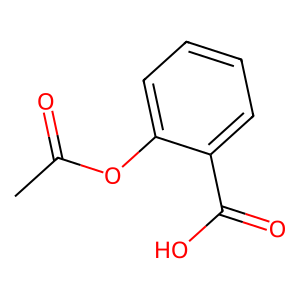

In [16]:
# Exercise
benzene = Chem.MolFromSmiles("c1ccccc1")
aspirin = Chem.MolFromSmiles("CC(=O)OC1=CC=CC=C1C(=O)O")

# Visualisation
Draw.MolToImage(benzene)
Draw.MolToImage(aspirin)

# Try to compute 
# Molecular weight
# NUmber of atoms
# Formula


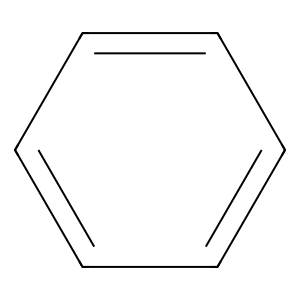

In [17]:
Draw.MolToImage(benzene)

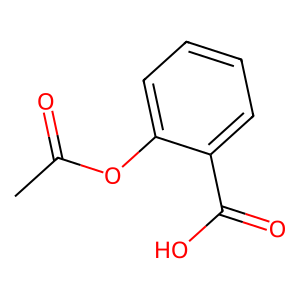

In [18]:
Draw.MolToImage(aspirin)

In [19]:
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem.Descriptors import MolWt

def get_info(molecule):
    print("----------------------------------------------------------------")
    print(f"Molecular weight: {MolWt(molecule)}")
    print(f"Molecular formula: {rdMolDescriptors.CalcMolFormula(molecule)}")
    print(f"Number of atoms in molecule: {molecule.GetNumAtoms()}")
    print("----------------------------------------------------------------")
    print("\n")

In [20]:
get_info(benzene)
get_info(aspirin)

----------------------------------------------------------------
Molecular weight: 78.11399999999999
Molecular formula: C6H6
Number of atoms in molecule: 6
----------------------------------------------------------------


----------------------------------------------------------------
Molecular weight: 180.15899999999996
Molecular formula: C9H8O4
Number of atoms in molecule: 13
----------------------------------------------------------------




## Molecular Descriptors and fingerprints

(important for AI and machine learning)
AI models can NOT read molecules (They ain't got eyes)
So we need to give them something they know, i.e. `Vectors`

These are called fingerprints

### 1) Molecular descriptors



In [21]:
# 1) Descriptors are simple chemical properties

from rdkit.Chem import Descriptors

Descriptors.MolWt(mol) # Gets molecular weight of molecules
Descriptors.NumHDonors(mol) # Gets number of hydrogen bond donors in a molecule
Descriptors.NumHAcceptors(mol) # Gets number of hydrogen bond acceptors in a molecule
Descriptors.TPSA(mol) # Gets topological polar surface area of a molecule

# These are widely used in QSAR models, drug discovery, ADMET prediction


20.23

In [22]:
print(f"Ethanol molecular weight: {Descriptors.MolWt(mol)}")
print(f"Ethanol number of hydrogen donor: {Descriptors.NumHDonors(mol)}")
print(f"Ethanol number of hydrogen acceptor: {Descriptors.NumHAcceptors(mol)}")

Ethanol molecular weight: 46.069
Ethanol number of hydrogen donor: 1
Ethanol number of hydrogen acceptor: 1


### 2. Molecular fingerprints

fingerprints encode structure patterns

The most common one is **Morgan fingerprint**

In [23]:
# 2) Molecule fingerprints

from rdkit.Chem import AllChem

fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=1024) # molecule, radius, nBits
fp

# Note that a `DEPRECATION WARNING MIGHT OCCUR`

[19:24:49] DEPRECATION WARNING: please use MorganGenerator


In [24]:
# so we use this

from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

generator = GetMorganGenerator(radius=2, fpSize=1024) 
fp = generator.GetFingerprint(mol)

# Note that radius in this case means distance in a graph 

In [25]:
fp # Now this works

In [26]:
# 3 Convert fingerprint to numpy array (for ML)

import numpy as np

arr = np.array(fp)
arr

# We can use this input for random forest, neural networks, clustering, similarity search

array([0, 0, 0, ..., 0, 0, 0], shape=(1024,))

In [27]:
# 4 Molecular similarity

from rdkit.DataStructs import TanimotoSimilarity

fp1 = generator.GetFingerprint(mol)
fp2 = generator.GetFingerprint(aspirin)

TanimotoSimilarity(fp1, fp2)

0.1111111111111111

In [28]:
silicon_dioxide = Chem.MolFromSmiles("[SiO2]")
silicon_dioxide

[19:24:49] SMILES Parse Error: syntax error while parsing: [SiO2]
[19:24:49] SMILES Parse Error: check for mistakes around position 4:
[19:24:49] [SiO2]
[19:24:49] ~~~^
[19:24:49] SMILES Parse Error: Failed parsing SMILES '[SiO2]' for input: '[SiO2]'
